### Load dataset and construct the L-ensemble

In [39]:
import datetime

import pandas as pd
import numpy as np

from utils import get_age_in_days, construct_L_Ensemble

df = pd.read_csv('tournesol_scores_above_20_2024-03-27.csv')

#Test parameters
bundle_size = 4
alphas = np.geomspace(start=0.1, stop=1000000, num=50)

##Model parameters
power = 2.8 
discount = 7.3
caracteristic_time = 31

recent_videos_proportion = 0.75
recent_videos_to_sample = int(bundle_size * recent_videos_proportion)
old_videos_to_sample = int(bundle_size * (1 - recent_videos_proportion))
                           
#Computes the age of each video
today = datetime.datetime(2024, 3, 28) #one day older than dataset
df['age_in_days'] = df.apply(lambda x: get_age_in_days(x, today), axis="columns")

dpps = [
    construct_L_Ensemble(df, power, discount, caracteristic_time, alpha=alpha)
    for alpha in alphas
]


L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi

### Measures the number of different channels per bundle

In [40]:
import seaborn as sns

n_tests = 1000

n_channel = pd.DataFrame(columns = ['channel_count', 'alpha'])

for i in range(len(alphas)):
    n_channel = pd.concat([
        n_channel,
        pd.DataFrame(
            [[len(df.loc[
                df.index[dpps[i].sample_exact_k_dpp(size=bundle_size)],
                'channel'
                ].unique())
              , alphas[i]]
            for _ in range(n_tests)],
            columns = ['channel_count', 'alpha']
        )
    ])

<AxesSubplot:xlabel='alpha', ylabel='proportion'>

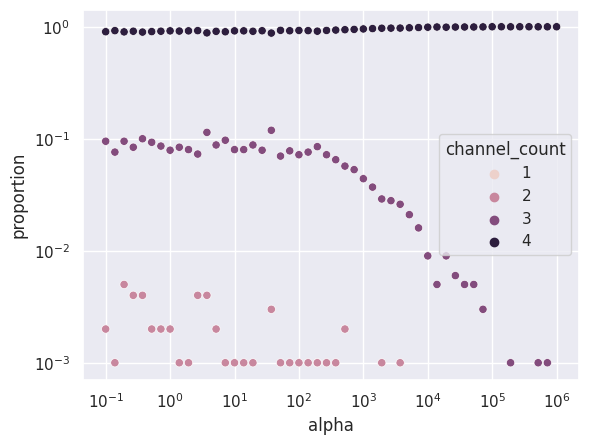

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

f, ax = plt.subplots()
ax.set_xscale('log')
ax.set_yscale('log')

n_channel_value_counts = n_channel.groupby('alpha', as_index=False).value_counts(normalize=True)

sns.set_theme(style='darkgrid')
sns.scatterplot(
    data=n_channel_value_counts,
    x='alpha',
    y='proportion',
    hue='channel_count',
    ax=ax
)


### View count, age and duration distributions

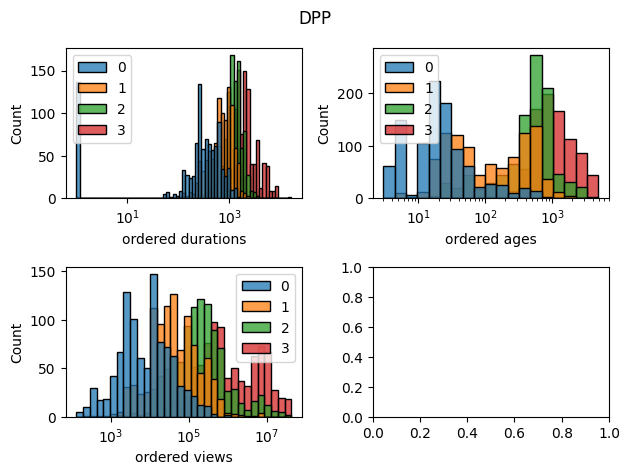

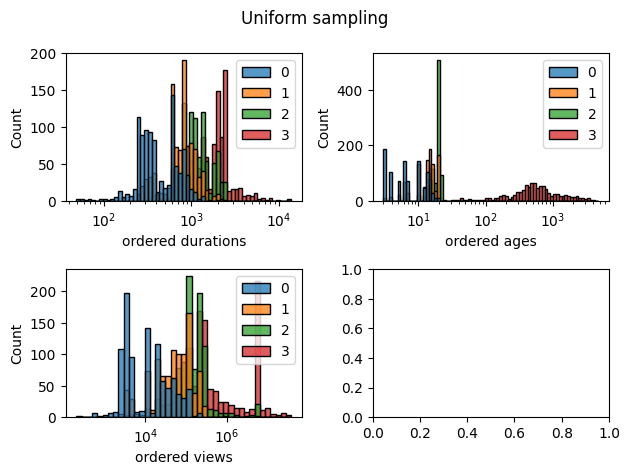

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

from utils import duration_in_secs

n_tests = 1000

#DPP
bundles_indexes = [
    dpp.sample_exact_k_dpp(size=bundle_size)
    for i in range(n_tests)
]

f, axs = plt.subplots(2, 2)

durations = df['duration'].apply(duration_in_secs)
ordered_duration = pd.DataFrame(
    data=[durations.loc[bundle_indexes]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[0,0].set_xlabel('ordered durations')
axs[0,0].set_xscale('log')
sns.histplot(data=ordered_duration, ax=axs[0,0])

ordered_age = pd.DataFrame(
    data=[df['age_in_days'].loc[bundle_indexes]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[0,1].set_xlabel('ordered ages')
axs[0,1].set_xscale('log')
sns.histplot(data=ordered_age, ax=axs[0, 1])

ordered_view_count = pd.DataFrame(
    data=[df['view_count'].loc[bundle_indexes]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[1,0].set_xlabel('ordered views')
axs[1,0].set_xscale('log')
sns.histplot(data=ordered_view_count, ax=axs[1, 0])

f.suptitle('DPP')
f.tight_layout()

#Uniform
bundles_indexes = [
    list(
        df.loc[df["age_in_days"] <= 21].sample(
            n=recent_videos_to_sample, 
            replace=False
        ).index
    )+
    list(
        df.loc[df["age_in_days"] > 21].sample(
            n=old_videos_to_sample, 
            replace=False
        ).index
    )
    for i in range(n_tests)
]

f, axs = plt.subplots(2, 2)

ordered_duration = pd.DataFrame(
    data=[durations.loc[bundle_indexes]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[0,0].set_xlabel('ordered durations')
axs[0,0].set_xscale('log')
sns.histplot(data=ordered_duration, ax=axs[0,0])

ordered_age = pd.DataFrame(
    data=[df['age_in_days'].loc[bundle_indexes]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[0,1].set_xlabel('ordered ages')
axs[0,1].set_xscale('log')
sns.histplot(data=ordered_age, ax=axs[0, 1])

ordered_view_count = pd.DataFrame(
    data=[df['view_count'].loc[bundle_indexes]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[1,0].set_xlabel('ordered views')
axs[1,0].set_xscale('log')
sns.histplot(data=ordered_view_count, ax=axs[1, 0])

f.suptitle('Uniform sampling')
f.tight_layout()

### Criteria maximums

In [42]:
from utils import CRITERIA

n_tests = 1000

maxs = df[CRITERIA].max()
mins = df[CRITERIA].min()

criteria_maximums = pd.DataFrame(columns = CRITERIA + ['sampling_method'])

for i in range(len(alphas)):
    criteria_maximums = pd.concat([
        criteria_maximums,
        pd.DataFrame(
            [pd.Series.to_list((df.loc[df.index[dpps[i].sample_exact_k_dpp(size=bundle_size)], CRITERIA].max()-mins)
                /(maxs-mins))+["alpha="+str(alphas[i])]
            for _ in range(n_tests)],
            columns = CRITERIA + ['sampling_method']
        )
    ])


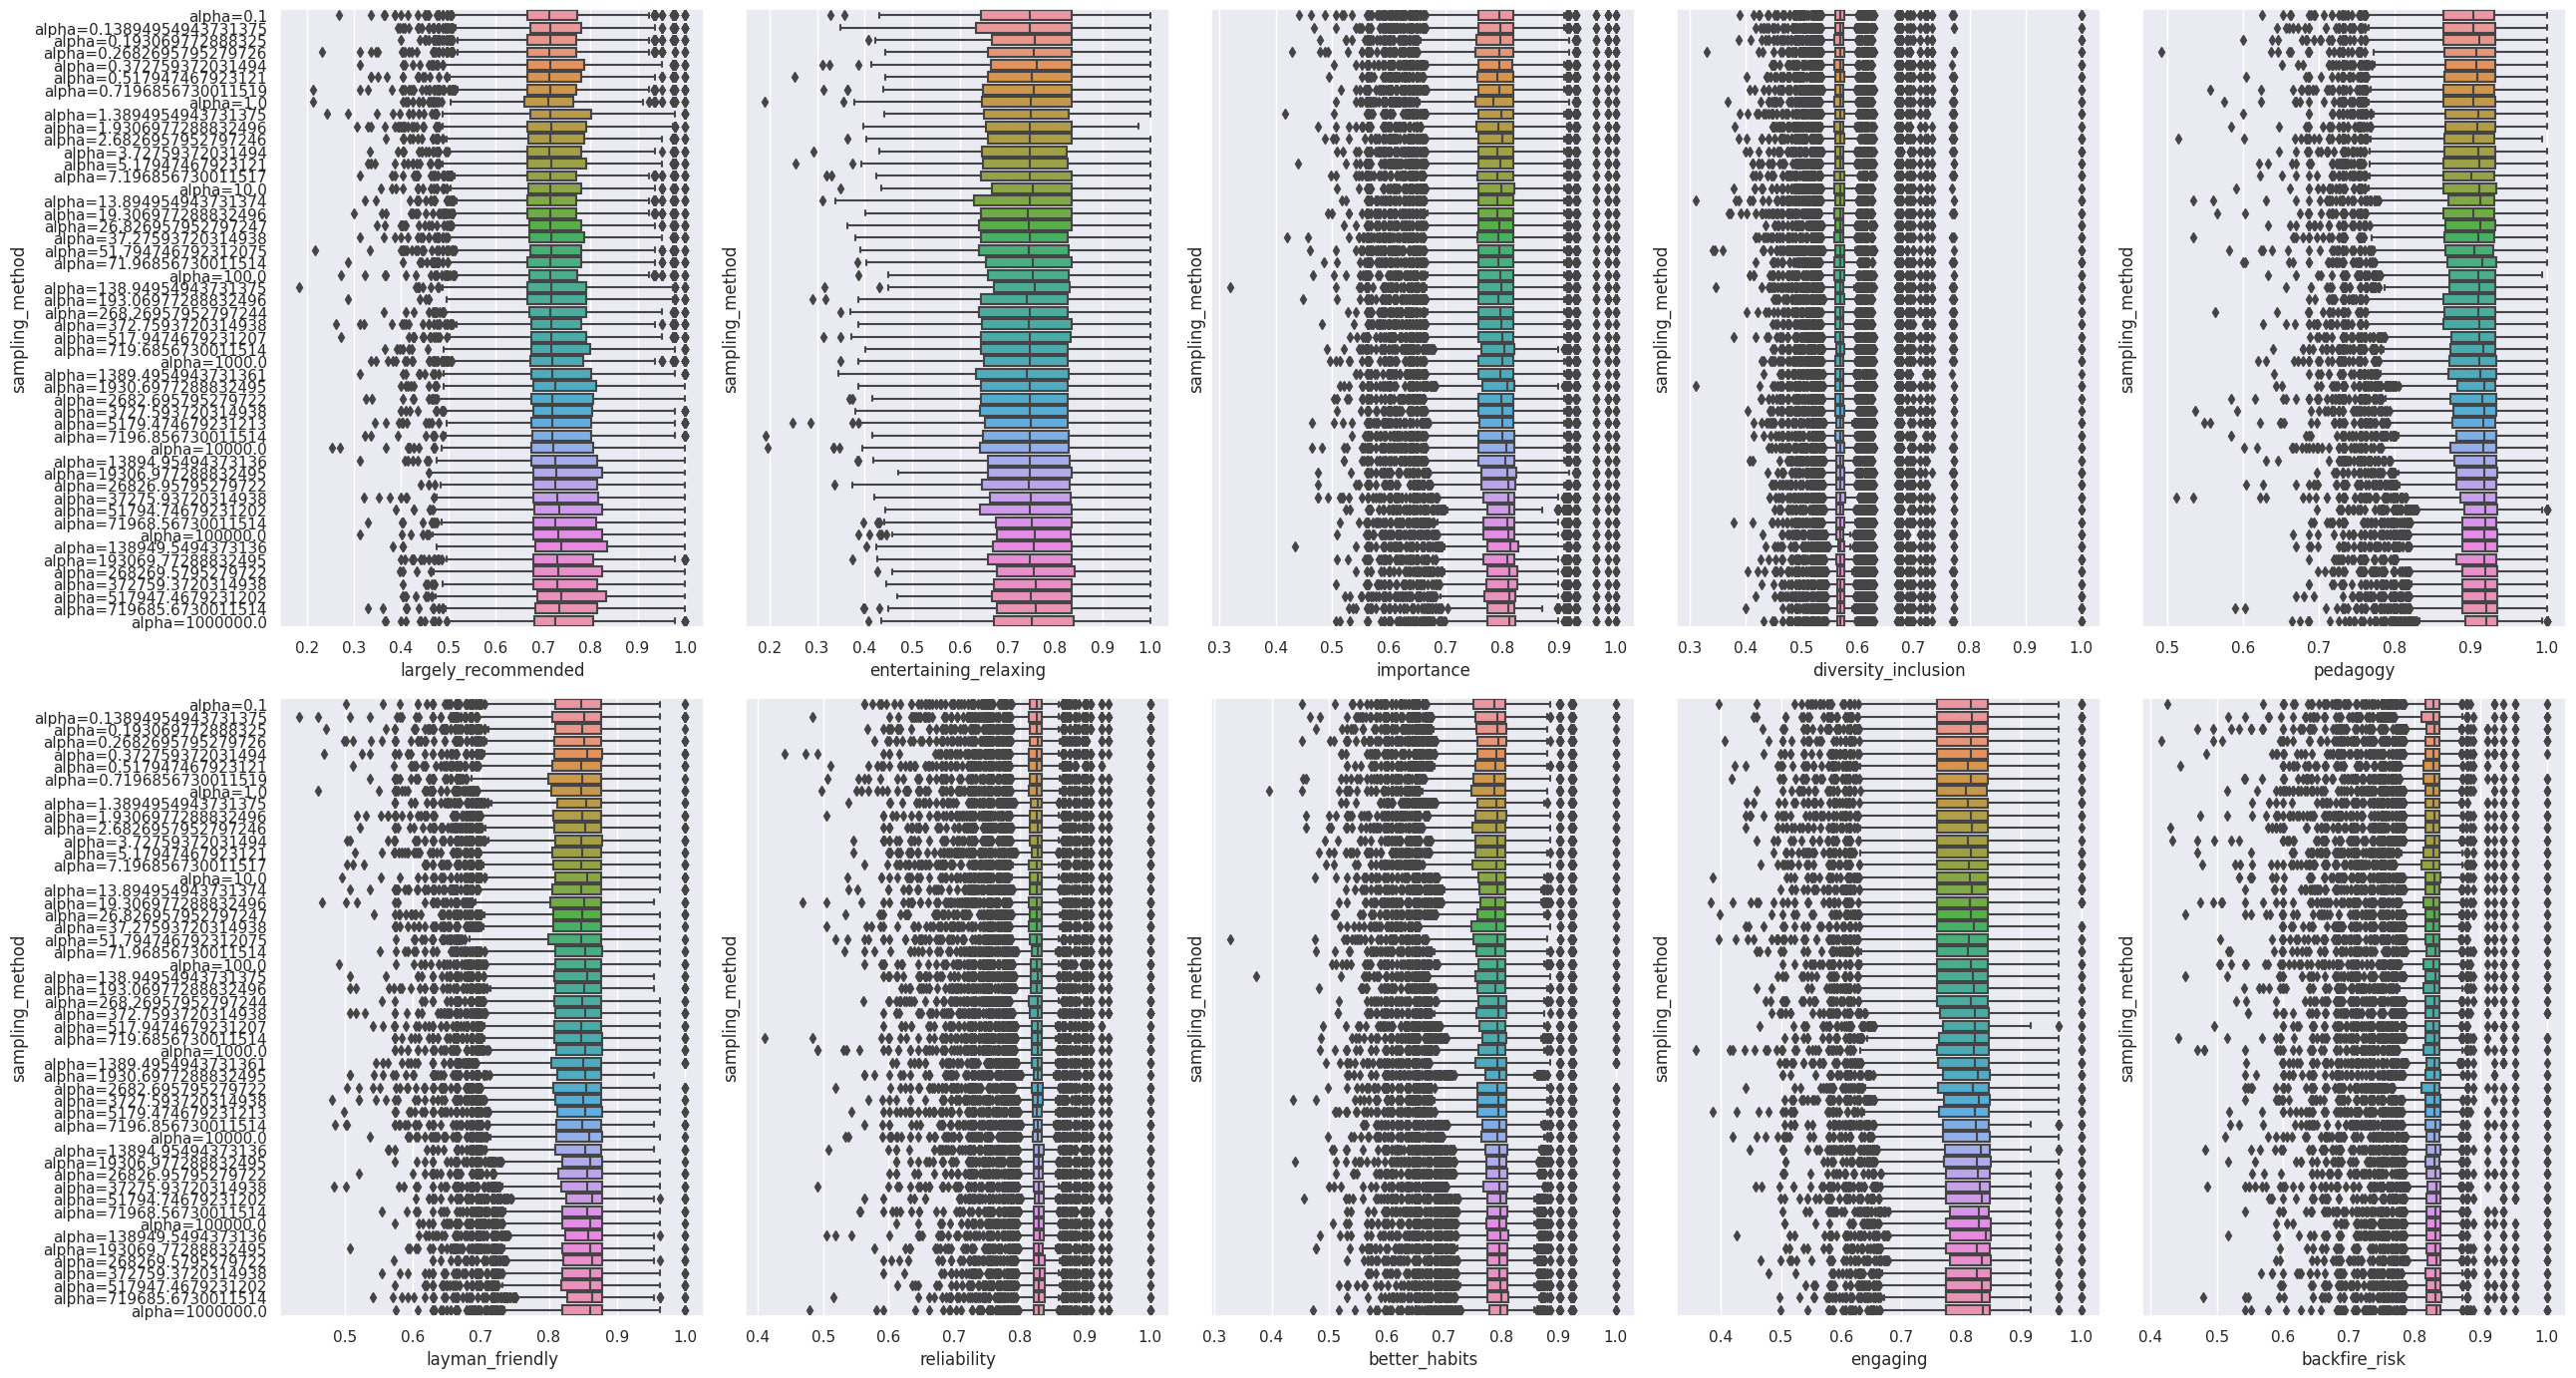

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

f, axs = plt.subplots(2, 5, figsize=(26,14), sharey=True)

for i in range(len(CRITERIA)):
    sns.boxplot(data=criteria_maximums,
                x=CRITERIA[i], 
                y='sampling_method',
                ax=axs[i % 2, i % 5]
    )

f.tight_layout()

### Determinants of bundle's features vectors

In [16]:
dpp.compute_L()

L (likelihood) kernel computed via:
- U diag(eig_L) U.T


<AxesSubplot:xlabel='determinant', ylabel='Count'>

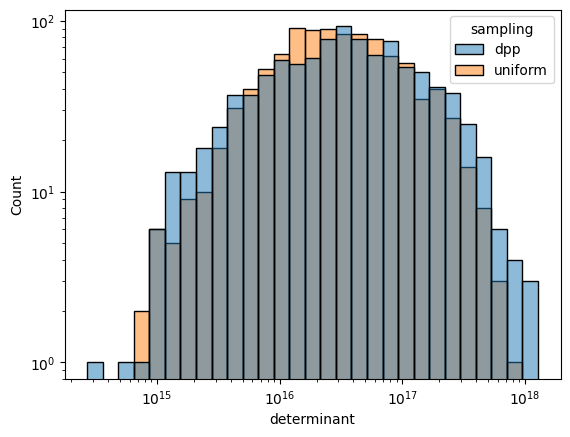

In [18]:
import seaborn as sns

n_tests = 1000

dpp_indexes = [
    dpp.sample_exact_k_dpp(size=bundle_size)
    for i in range(n_tests)
]

uniform_indexes = [
    list(
        df.loc[df["age_in_days"] <= 21].sample(
            n=recent_videos_to_sample, 
            replace=False
        ).index
    )+
    list(
        df.loc[df["age_in_days"] > 21].sample(
            n=old_videos_to_sample, 
            replace=False
        ).index
    )
    for i in range(n_tests)
]

determinants = pd.DataFrame(
    columns = ['determinant', 'sampling'],
    data = [
        [
            np.abs(np.linalg.det(
                np.linalg.qr(dpp.L_gram_factor[:, indexes])[1]
            ))
        ] + ['dpp']
        for indexes in dpp_indexes
    ] +
    [
        [
            np.abs(np.linalg.det(
                np.linalg.qr(dpp.L_gram_factor[:, indexes])[1]
            ))
        ] + ['uniform']
        for indexes in uniform_indexes
    ]
)

sns.histplot(data=determinants, 
             x='determinant', 
             hue='sampling',
             log_scale=(True, True)
)
        

# Fairness

### Compute singleton marginals and qualities

L (likelihood) kernel computed via:
- L = Phi.T Phi, where Phi = L_gram_factor


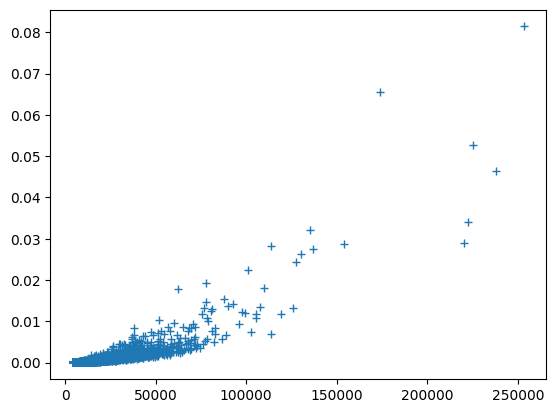

In [2]:
import matplotlib.pyplot as plt
from dppy.exact_sampling import elementary_symmetric_polynomials

dpp.compute_L()
evals, evecs = np.linalg.eigh(dpp.L)

rank_L, n_videos = dpp.L_gram_factor.shape
bundle_size = 4

e_N_k = elementary_symmetric_polynomials(
    eig_vals = evals, 
    size = bundle_size
)[bundle_size, n_videos]

partials_e_N_k_minus_one = np.array([
    elementary_symmetric_polynomials(
        eig_vals = np.concatenate((evals[:i], evals[i + 1 :])), 
        size = bundle_size - 1
    )[bundle_size-1, n_videos-1]
    for i in range(n_videos-rank_L+1, n_videos+1)
])

#using formula (205) page 64
singletons_marginals = np.array([
    (evals[n_videos-rank_L:]*
    evecs[i,n_videos-rank_L:]**2
    ).dot(1/e_N_k*partials_e_N_k_minus_one)
    for i in range(n_videos)
])

qualities = np.array([
    np.sqrt(dpp.L_gram_factor[:,i].dot(dpp.L_gram_factor[:,i]))
    for i in range(n_videos)
])

### Plot

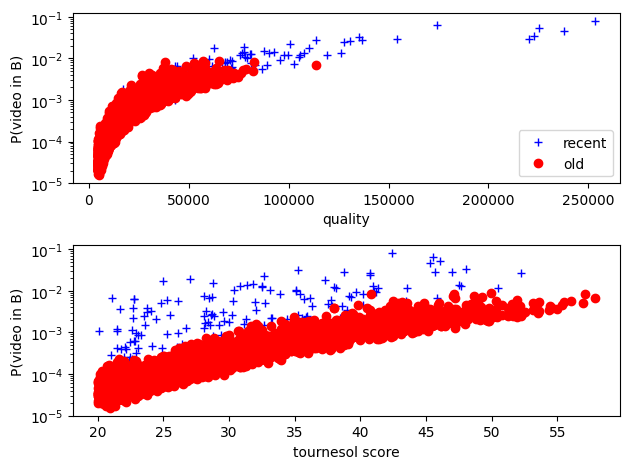

In [27]:
age_threshold = 3*caracteristic_time

recent_videos_indexes = df.loc[
    df['age_in_days'] <= age_threshold
].index

old_videos_indexes = df.loc[
    df['age_in_days'] > age_threshold
].index

f, axes = plt.subplots(2, 1)

axes[0].plot(qualities[recent_videos_indexes], 
             singletons_marginals[recent_videos_indexes], 
             'b+',
             label='recent'
)
axes[0].plot(qualities[old_videos_indexes], 
             singletons_marginals[old_videos_indexes], 
             'ro',
             label='old'
)
axes[0].set_xlabel('quality')
axes[0].set_ylabel('P(video in B)')
axes[0].set_yscale('log')
axes[0].legend()

axes[1].plot(
    df['largely_recommended'].to_numpy()[recent_videos_indexes], 
    singletons_marginals[recent_videos_indexes], 
    'b+',
)
axes[1].plot(
    df['largely_recommended'].to_numpy()[old_videos_indexes], 
    singletons_marginals[old_videos_indexes], 
    'ro'
)
axes[1].set_xlabel('tournesol score')
axes[1].set_ylabel('P(video in B)')
axes[1].set_yscale('log')

f.tight_layout()